In [2]:
"""SD3.5-L Prompt-based Image Editing

Based on: "Exploring Multimodal Diffusion Transformers for Enhanced Prompt-based Image Editing"
"""

import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusion3Pipeline

import sys
sys.path.append("..")
from utils import (
    register_qkv_control,
    create_qkv_controller,
    p2p_callback,
    TOP5_BLOCKS,
)

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3.5-large", torch_dtype=torch.bfloat16
).to("cuda")

/opt/conda/envs/exp-mmdit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 9/9 [00:01<00:00,  5.64it/s]


Registered 38 attention processors (SDPA: True).


100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


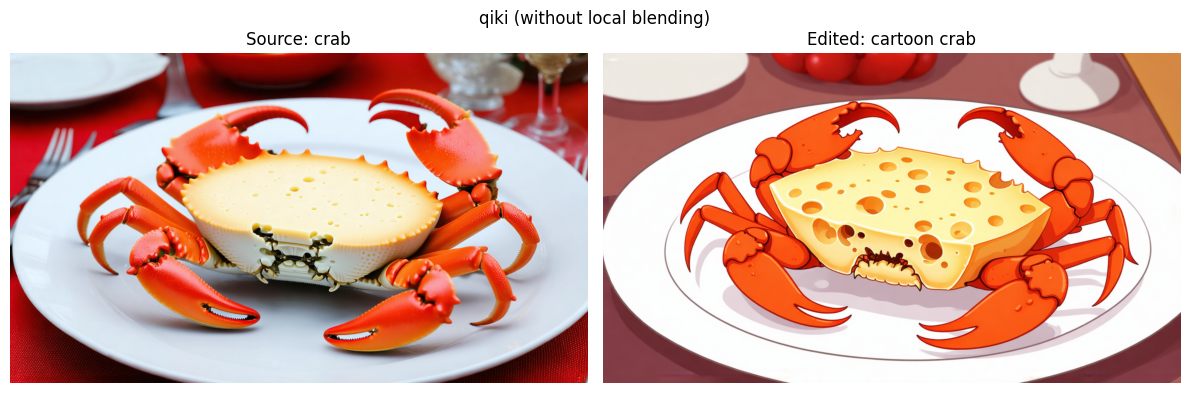

In [3]:
# Replace (qiki) - without local blending

prompts = [
    "A crab made of cheese on a plate",
    "A cartoon-style drawing of a crab made of cheese on a plate"
]
height, width = 768, 1344
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(3273489), torch.Generator().manual_seed(3273489)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(images[0])
ax[0].set_title("Source: crab")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: cartoon crab")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 38 attention processors (SDPA: True).


100%|██████████| 28/28 [00:50<00:00,  1.80s/it]


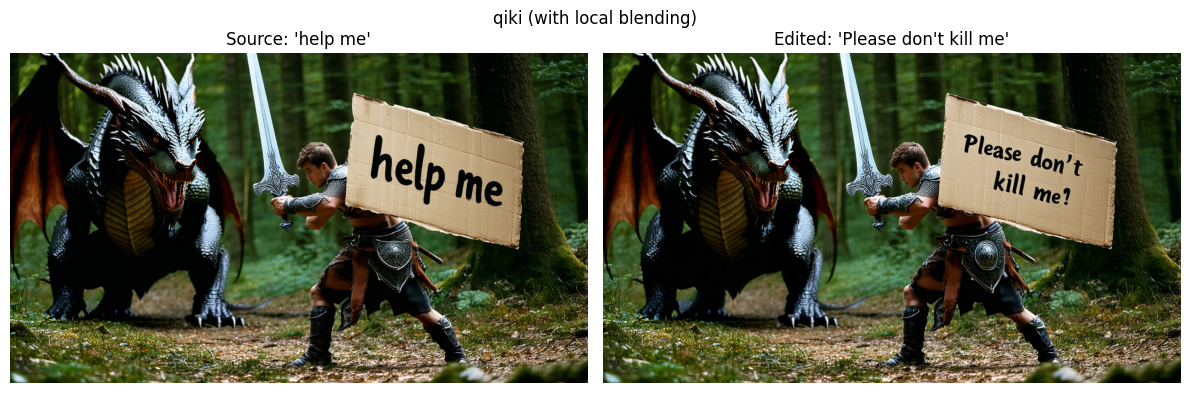

In [4]:
# Replace (qiki) - with local blending

prompts = [
    "a guy in the forest with a sword and shield, fighting a dragon, holding a large sign 'help me'",
    "a guy in the forest with a sword and shield, fighting a dragon, holding a large sign 'Please don't kill me'"
]
height, width = 768, 1344
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=[["'help me'"], ["'Please don't kill me'"]],
    local_blend_threshold=0.5,
    aggregate_blocks=TOP5_BLOCKS["sd3.5-l"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(9999974747), torch.Generator().manual_seed(9999974747)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(images[0])
ax[0].set_title("Source: 'help me'")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: 'Please don't kill me'")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 38 attention processors (SDPA: True).


100%|██████████| 28/28 [00:51<00:00,  1.83s/it]


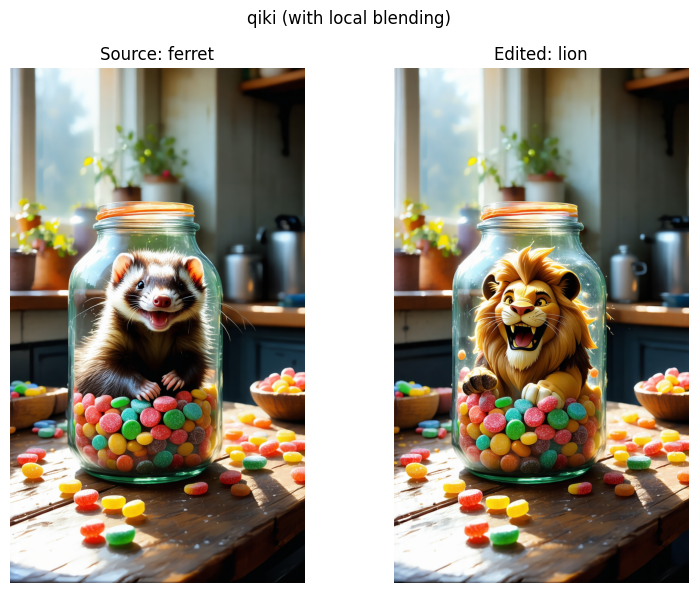

In [5]:
# Replace (qiki) - with local blending

prompts = [
    "A mischievous ferret with a playful grin squeezes itself into a large glass jar, surrounded by colorful candy. The jar sits on a wooden table in a cozy kitchen, and warm sunlight filters through a nearby window",
    "A mischievous lion with a playful grin squeezes itself into a large glass jar, surrounded by colorful candy. The jar sits on a wooden table in a cozy kitchen, and warm sunlight filters through a nearby window",
]
height, width = 1344, 768
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=[["ferret"], ["lion"]],
    local_blend_threshold=0.5,
    aggregate_blocks=TOP5_BLOCKS["sd3.5-l"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(123412341234), torch.Generator().manual_seed(123412341234)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: ferret")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: lion")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

In [6]:
del pipe
torch.cuda.empty_cache()
print("Done!")

Done!
